Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']
Number of samples per class: [212 357]
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Model accuracy: 0.9649

Decision Tree Structure:
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- mean texture <= 16.19
|   |   |   |--- class: 1
|   |   |--- mean texture >  16.19
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst texture <= 20.40
|   |   |--- mean concave points <= 0.09
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.09
|   |   |   |--- class: 0
|   |--- worst texture >  20.40
|   |   |--- worst area <= 718.65
|   |   |   |--- class: 1
|   |   |--- worst area >  718.65
|   |   |   |--- class: 0


Sample #0 from test set:
True label: benign
Predicted labe

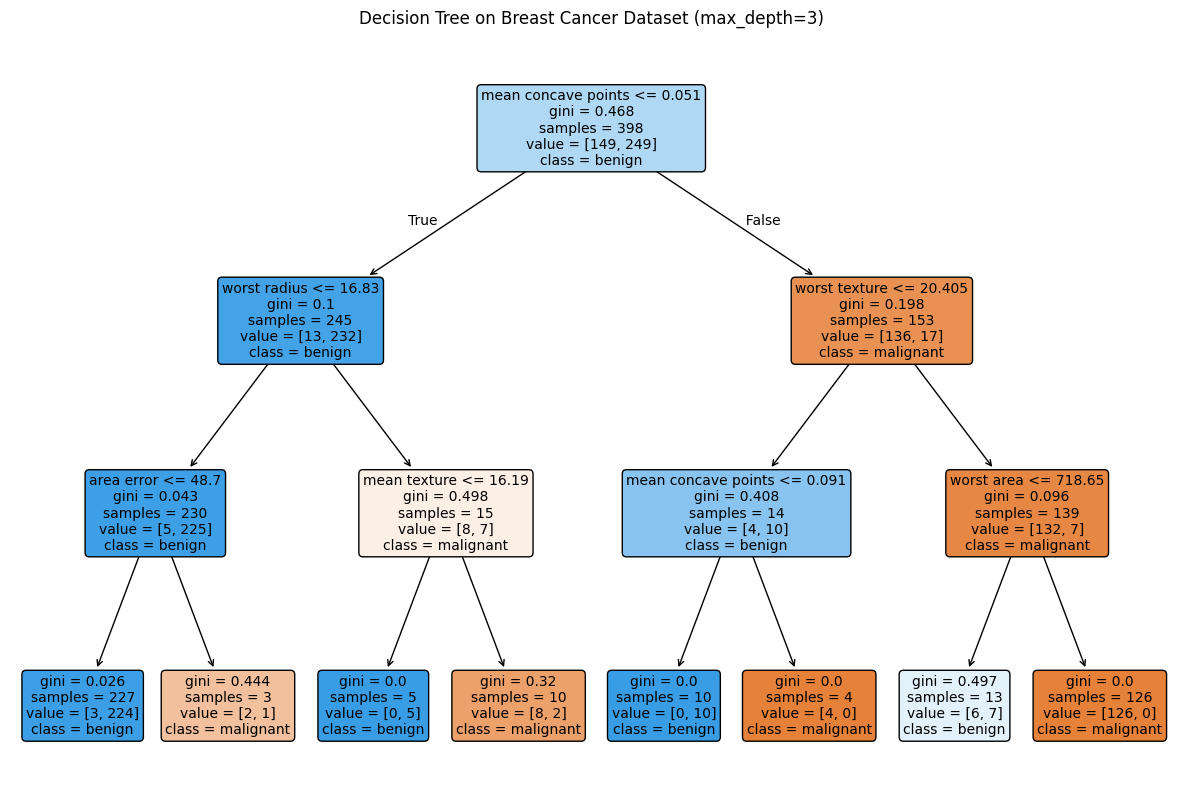

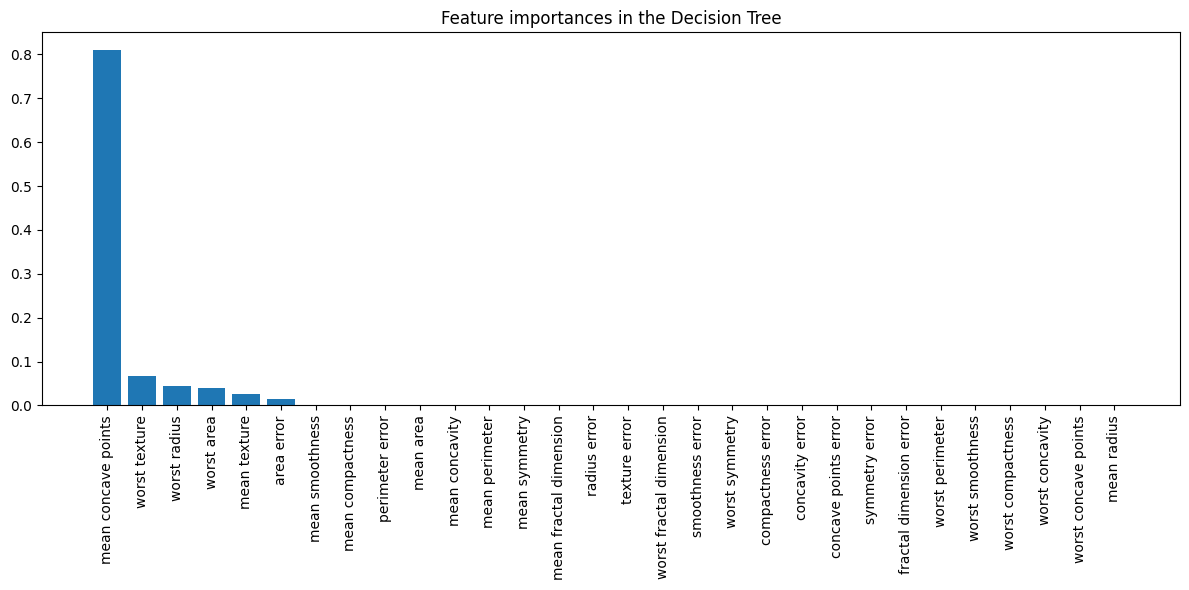

In [1]:
# Decision trees 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set a random state for reproducibility
RANDOM_STATE = 42

# Load the breast cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target
feature_names = breast_cancer.feature_names
target_names = breast_cancer.target_names

print(f"Dataset shape: {X.shape}")
print(f"Target classes: {target_names}")
print(f"Number of samples per class: {np.bincount(y)}")
print(f"First 5 feature names: {feature_names[:5]}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# Train a decision tree (limiting to 3 levels for visualization purposes)
clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

# Check accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f}")

# Display the tree structure as text
tree_text = export_text(clf, feature_names=feature_names)
print("\nDecision Tree Structure:")
print(tree_text)

# Let's trace a prediction for a specific test example
sample_idx = 0  # Choose the first sample from the test set
test_sample = X_test[sample_idx:sample_idx+1]  # Get the sample as a 2D array
true_label = y_test[sample_idx]
pred_label = clf.predict(test_sample)[0]

print(f"\nSample #{sample_idx} from test set:")
print(f"True label: {target_names[true_label]}")
print(f"Predicted label: {target_names[pred_label]}")

# Let's manually trace the prediction path
def trace_prediction_path(tree, sample):
    """Manually trace the prediction path for a sample through the decision tree."""
    # Get tree attributes
    children_left = tree.children_left
    children_right = tree.children_right
    feature = tree.feature
    threshold = tree.threshold
    values = tree.value
    
    # Start from the root node (index 0)
    node_id = 0
    
    # Format the sample values for better readability
    sample_values = sample[0]
    
    print("\nTracing prediction path step by step:")
    while children_left[node_id] != children_right[node_id]:  # While not a leaf node
        # Get the feature and threshold for this node
        feat_idx = feature[node_id]
        feat_name = feature_names[feat_idx]
        feat_value = sample_values[feat_idx]
        feat_threshold = threshold[node_id]
        
        # Print the decision at this node
        if feat_value <= feat_threshold:
            print(f"Node {node_id}: Is {feat_name} ({feat_value:.4f}) <= {feat_threshold:.4f}? YES")
            node_id = children_left[node_id]
        else:
            print(f"Node {node_id}: Is {feat_name} ({feat_value:.4f}) <= {feat_threshold:.4f}? NO")
            node_id = children_right[node_id]
    
    # We've reached a leaf node
    class_counts = values[node_id][0]
    majority_class = np.argmax(class_counts)
    class_probabilities = class_counts / np.sum(class_counts)
    
    print(f"Reached leaf node {node_id}")
    print(f"Class counts in this leaf: {class_counts}")
    print(f"Class probabilities: {class_probabilities}")
    print(f"Predicted class: {target_names[majority_class]}")
    
    return node_id, majority_class

# Trace the prediction
leaf_node, predicted_class = trace_prediction_path(clf.tree_, test_sample)

# Visualize the decision tree
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree on Breast Cancer Dataset (max_depth=3)")
plt.savefig('decision_tree_visualization.png')
print("\nDecision tree visualization saved to 'decision_tree_visualization.png'")

# Get feature importances
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = [(feature_names[i], importances[i]) for i in indices[:5]]
print("\nTop 5 important features:")
for name, importance in top_features:
    print(f"{name}: {importance:.4f}")

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.title('Feature importances in the Decision Tree')
plt.tight_layout()
plt.savefig('feature_importances.png')
print("\nFeature importances visualization saved to 'feature_importances.png'")